# PLSC (behavior/seed PLSC)

Partial least squares correlation (PLSC; [Abdi & Williams, 2012](https://doi.org/10.1007/978-1-62703-059-5_23)), also known as behaviour PLSC or seed PLSC ([Krishnan et al., 2011](https://doi.org/10.1016/j.neuroimage.2010.07.034)), is a method for identifying latent patterns of shared variance between two sets of variables by decomposing correlation matrices that are stratified by experimental condition.

## Setting up simulated data

We'll simulate data in which a single latent variable explains the relatinoship between a set of 50 observed variables in the data array and a set of 4 covariates. The latent variable will have a sinusoidal pattern of loadings onto the observed variables, and positive loadings onto all of the covariates. First, we will import the necessary libraries and seed the random number generator for reproducibility:

In [6]:
import numpy as np
import pandas as pd
from pyplsc import PLSC
from matplotlib import pyplot as plt

np.random.seed(123)

Next, we will simulate the underlying latent variable, which will be normally distributed.

In [7]:
n_subj = 40
latent_var = np.random.normal(size=(n_subj, 1))

Next, we will create a set of sinusoidal loadings:

In [9]:
n_var = 50
data_loadings = np.sin(0.2*np.arange(n_var)).reshape(1, n_var) # Sinusoidal loading pattern

The following displays the pattern of loadings onto the observed variables:

Text(0, 0.5, 'Correlation weight')

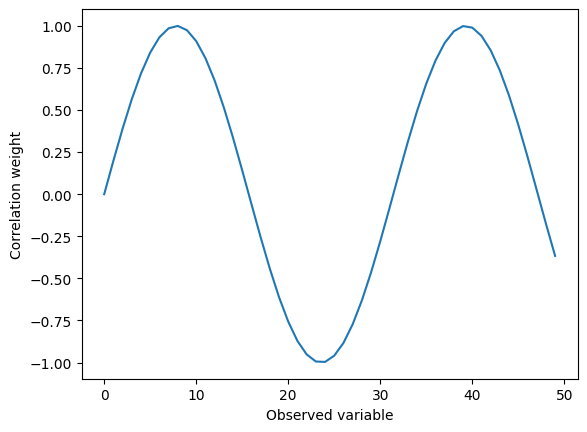

In [15]:
plt.plot(data_loadings.T)
plt.xlabel('Observed variable')
plt.ylabel('Correlation weight')

Next, we can compute the data array as the latent variable multiplied by the loadings, plus some noise:

In [16]:
data_noise = 0.5*np.random.normal(size=(n_subj, n_var))
data = latent_var @ data_loadings + data_noise

Next, we will simulate the covariates:

In [19]:
n_cov = 4
cov_noise = np.random.normal(size=(n_subj, n_cov))
covariates = latent_var + cov_noise # Effectively all loadings of 1

## Fitting and evaluating the model

Since the data are not stratified by any experimental condition, we can fit the model by simply providing the data array and the covariates withut a design matrix specifying conditions:

In [26]:
mod = PLSC(random_state=123) # Seed for reproducibility
mod.fit(data=data,
        covariates=covariates)

We can use permutation testing to evaluate the significance of the latent variables identified by the model. This yields one $p$ value per singular value:

In [27]:
mod.permute(1000)
print(mod.pvals_)
is_sig = mod.pvals_ < 0.05
sig_lvs = np.where(is_sig)[0]
print(sig_lvs)

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4361.66it/s]

[0.000999   0.87112887 0.41158841 0.89310689]
[0]


Thus there is one significant pair of latent variables, in line with how we simulated the data. Next, we can perform bootstrap resampling to assess the reliability of the data saliences and to evaluate how reliably each latent variable correlates with each covariate. We will see shortly how to visualize the results of resampling.

In [28]:
mod.bootstrap(1000)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1760.23it/s]


## Visualizing the model

Next we will visualize each significant latent variable.

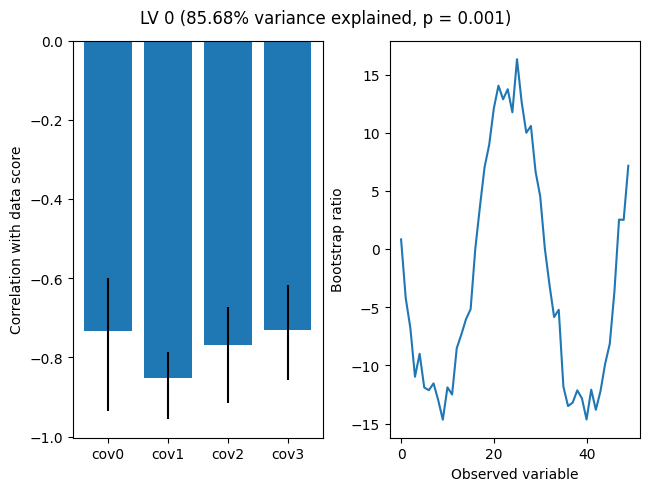

In [32]:
labels = mod.design_sal_labels_['covariate']
n_sig = len(sig_lvs)

fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=n_sig)
if n_sig == 1:
    subfigs = [subfigs]

for plot_idx, lv_idx in enumerate(sig_lvs):
    subfig = subfigs[plot_idx]
    subfig.suptitle('LV %s (%.2f%% variance explained, p = %.3f)' % (
        lv_idx,
        100*mod.variance_explained_[lv_idx],
        mod.pvals_[lv_idx]))
    ax = subfig.subplots(ncols=2)
    ax[0].bar(x=labels,
              height=mod.boot_stat_val_[:, lv_idx],
              yerr=mod.get_boot_stat_yerr(lv_idx))
    ax[0].set_ylabel('Correlation with data score')
    ax[1].plot(mod.bootstrap_ratios_[:, lv_idx])
    ax[1].set_ylabel('Bootstrap ratio')
    ax[1].set_xlabel('Observed variable')


As we can see, the boostrap ratios are roughly sinusoidal. `mod.flip_signs(lv_idx=0)` can be used to obtain an equivalent solution in which the covariates have positive correlations with the latent variable.